In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("player_experiment.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 14)


,player_id,experiment_group,platform,country,sessions,avg_session_minutes,total_playtime_minutes,levels_completed,d1_retention,d7_retention,purchase,revenue,booster_usage,failures
0,1,Control,Android,USA,5,4.43,22.16,4,0,0,0,0.0,0,1
1,2,Treatment,Android,USA,9,8.38,75.42,24,1,0,0,0.0,4,9
2,3,Treatment,iOS,Turkey,9,8.95,80.55,18,1,1,0,0.0,5,4
3,4,Treatment,Android,USA,9,8.54,76.84,14,1,0,0,0.0,4,3
4,5,Control,iOS,USA,10,9.37,93.72,12,0,1,0,0.0,0,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   player_id               100000 non-null  int64  
 1   experiment_group        100000 non-null  object 
 2   platform                100000 non-null  object 
 3   country                 100000 non-null  object 
 4   sessions                100000 non-null  int64  
 5   avg_session_minutes     100000 non-null  float64
 6   total_playtime_minutes  100000 non-null  float64
 7   levels_completed        100000 non-null  int64  
 8   d1_retention            100000 non-null  int64  
 9   d7_retention            100000 non-null  int64  
 10  purchase                100000 non-null  int64  
 11  revenue                 100000 non-null  float64
 12  booster_usage           100000 non-null  int64  
 13  failures                100000 non-null  int64  
dtypes: float64(3), int64(

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate players:")
print(df["player_id"].duplicated().sum())

Missing values:
player_id                 0
experiment_group          0
platform                  0
country                   0
sessions                  0
avg_session_minutes       0
total_playtime_minutes    0
levels_completed          0
d1_retention              0
d7_retention              0
purchase                  0
revenue                   0
booster_usage             0
failures                  0
dtype: int64

Duplicate players:
0


In [5]:
group_counts = df["experiment_group"].value_counts()
group_percentages = df["experiment_group"].value_counts(normalize=True) * 100

randomization_check = pd.DataFrame({
    "Players": group_counts,
    "Percentage": group_percentages.round(2)
})

randomization_check

,Players,Percentage
experiment_group,,
Treatment,50066,50.07
Control,49934,49.93


In [6]:
experiment_summary = df.groupby("experiment_group").agg(
    players=("player_id", "count"),
    avg_sessions=("sessions", "mean"),
    avg_playtime=("total_playtime_minutes", "mean"),
    avg_levels_completed=("levels_completed", "mean"),
    d1_retention=("d1_retention", "mean"),
    d7_retention=("d7_retention", "mean"),
    conversion_rate=("purchase", "mean"),
    arpu=("revenue", "mean")
)

experiment_summary[
    ["d1_retention", "d7_retention", "conversion_rate"]
] *= 100

experiment_summary.round(2)

,players,avg_sessions,avg_playtime,avg_levels_completed,d1_retention,d7_retention,conversion_rate,arpu
experiment_group,,,,,,,,
Control,49934,8.01,71.61,14.38,42.20,24.88,7.40,0.88
Treatment,50066,8.71,78.55,15.69,43.59,27.17,7.68,0.93


## Statistical A/B Test – D7 Retention

### Hypothesis

H0: There is no difference in D7 retention between the Control and Treatment groups.

H1: The Treatment group has a different D7 retention rate compared with the Control group.

Significance level: α = 0.05

In [7]:
from statsmodels.stats.proportion import proportions_ztest

control = df[df["experiment_group"] == "Control"]["d7_retention"]
treatment = df[df["experiment_group"] == "Treatment"]["d7_retention"]

successes = [
    control.sum(),
    treatment.sum()
]

observations = [
    len(control),
    len(treatment)
]

z_stat, p_value = proportions_ztest(
    count=successes,
    nobs=observations
)

print(f"Control D7 Retention: {control.mean():.4%}")
print(f"Treatment D7 Retention: {treatment.mean():.4%}")
print(f"Absolute Difference: {(treatment.mean() - control.mean()):.4%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Control D7 Retention: 24.8788%
Treatment D7 Retention: 27.1741%
Absolute Difference: 2.2953%
Z-statistic: -8.2709
P-value: 0.000000


## Confidence Interval for D7 Retention Uplift

In [8]:
import numpy as np
from scipy.stats import norm

p_control = control.mean()
p_treatment = treatment.mean()

n_control = len(control)
n_treatment = len(treatment)

difference = p_treatment - p_control

standard_error = np.sqrt(
    (p_control * (1 - p_control) / n_control) +
    (p_treatment * (1 - p_treatment) / n_treatment)
)

z_critical = norm.ppf(0.975)

ci_lower = difference - z_critical * standard_error
ci_upper = difference + z_critical * standard_error

print(f"Estimated uplift: {difference:.4%}")
print(f"95% CI: [{ci_lower:.4%}, {ci_upper:.4%}]")

Estimated uplift: 2.2953%
95% CI: [1.7516%, 2.8390%]


## Guardrail Metrics: Monetization Impact

Although D7 retention is the primary experiment metric, a successful feature
should not negatively affect monetization.

Therefore, conversion rate and ARPU are evaluated as guardrail metrics.

In [9]:
monetization_summary = df.groupby("experiment_group").agg(
    players=("player_id", "count"),
    purchasers=("purchase", "sum"),
    conversion_rate=("purchase", "mean"),
    total_revenue=("revenue", "sum"),
    arpu=("revenue", "mean")
)

monetization_summary["conversion_rate"] *= 100

monetization_summary.round(3)

,players,purchasers,conversion_rate,total_revenue,arpu
experiment_group,,,,,
Control,49934,3697,7.404,44009.73,0.881
Treatment,50066,3845,7.680,46755.97,0.934


In [10]:
control_purchase = df[
    df["experiment_group"] == "Control"
]["purchase"]

treatment_purchase = df[
    df["experiment_group"] == "Treatment"
]["purchase"]

successes = [
    control_purchase.sum(),
    treatment_purchase.sum()
]

observations = [
    len(control_purchase),
    len(treatment_purchase)
]

z_stat_conversion, p_value_conversion = proportions_ztest(
    count=successes,
    nobs=observations
)

conversion_difference = (
    treatment_purchase.mean() - control_purchase.mean()
)

print(f"Control Conversion: {control_purchase.mean():.4%}")
print(f"Treatment Conversion: {treatment_purchase.mean():.4%}")
print(f"Absolute Difference: {conversion_difference:.4%}")
print(f"Z-statistic: {z_stat_conversion:.4f}")
print(f"P-value: {p_value_conversion:.6f}")

Control Conversion: 7.4038%
Treatment Conversion: 7.6799%
Absolute Difference: 0.2761%
Z-statistic: -1.6531
P-value: 0.098307


In [11]:
control_revenue = df[
    df["experiment_group"] == "Control"
]["revenue"]

treatment_revenue = df[
    df["experiment_group"] == "Treatment"
]["revenue"]

print(f"Control ARPU: {control_revenue.mean():.4f}")
print(f"Treatment ARPU: {treatment_revenue.mean():.4f}")

arpu_difference = (
    treatment_revenue.mean() - control_revenue.mean()
)

print(f"Absolute ARPU Difference: {arpu_difference:.4f}")

relative_arpu_change = (
    arpu_difference / control_revenue.mean()
) * 100

print(f"Relative ARPU Change: {relative_arpu_change:.2f}%")

Control ARPU: 0.8814
Treatment ARPU: 0.9339
Absolute ARPU Difference: 0.0525
Relative ARPU Change: 5.96%


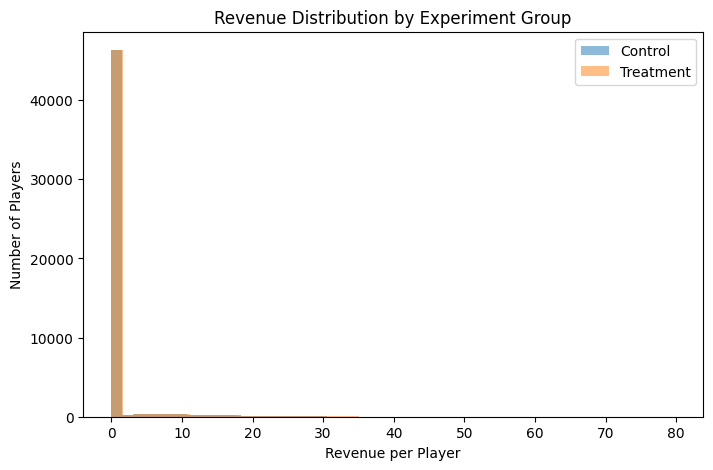

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    control_revenue,
    bins=50,
    alpha=0.5,
    label="Control"
)

plt.hist(
    treatment_revenue,
    bins=50,
    alpha=0.5,
    label="Treatment"
)

plt.xlabel("Revenue per Player")
plt.ylabel("Number of Players")
plt.title("Revenue Distribution by Experiment Group")
plt.legend()

plt.show()

## Bootstrap Analysis of ARPU

Revenue per player is highly right-skewed because most players generate zero
revenue while a relatively small proportion of players make purchases.

Therefore, a bootstrap approach is used to estimate the uncertainty around
the difference in ARPU between the Treatment and Control groups without
relying heavily on normality assumptions.

In [13]:
rng = np.random.default_rng(42)

n_bootstrap = 5000
bootstrap_differences = []

control_values = control_revenue.to_numpy()
treatment_values = treatment_revenue.to_numpy()

for _ in range(n_bootstrap):

    control_sample = rng.choice(
        control_values,
        size=len(control_values),
        replace=True
    )

    treatment_sample = rng.choice(
        treatment_values,
        size=len(treatment_values),
        replace=True
    )

    difference = (
        treatment_sample.mean()
        - control_sample.mean()
    )

    bootstrap_differences.append(difference)

bootstrap_differences = np.array(bootstrap_differences)

ci_lower = np.percentile(bootstrap_differences, 2.5)
ci_upper = np.percentile(bootstrap_differences, 97.5)

observed_difference = (
    treatment_values.mean()
    - control_values.mean()
)

print(f"Control ARPU: {control_values.mean():.4f}")
print(f"Treatment ARPU: {treatment_values.mean():.4f}")
print(f"Observed Difference: {observed_difference:.4f}")
print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

Control ARPU: 0.8814
Treatment ARPU: 0.9339
Observed Difference: 0.0525
95% Bootstrap CI: [0.0029, 0.1015]


## Paying Player Analysis (ARPPU)

The conversion rate did not show a statistically significant difference between
the experiment groups, while Treatment showed a positive ARPU uplift.

To better understand this result, the spending behavior of paying players is
analyzed using Average Revenue Per Paying User (ARPPU).

In [14]:
paying_players = df[df["purchase"] == 1]

arppu_summary = paying_players.groupby("experiment_group").agg(
    paying_players=("player_id", "count"),
    total_revenue=("revenue", "sum"),
    arppu=("revenue", "mean"),
    median_revenue=("revenue", "median")
)

arppu_summary.round(3)

,paying_players,total_revenue,arppu,median_revenue
experiment_group,,,,
Control,3697,44009.73,11.904,10.04
Treatment,3845,46755.97,12.160,10.10


In [15]:
control_payers = paying_players[
    paying_players["experiment_group"] == "Control"
]["revenue"].to_numpy()

treatment_payers = paying_players[
    paying_players["experiment_group"] == "Treatment"
]["revenue"].to_numpy()

print(f"Control ARPPU: {control_payers.mean():.4f}")
print(f"Treatment ARPPU: {treatment_payers.mean():.4f}")

arppu_difference = (
    treatment_payers.mean() - control_payers.mean()
)

print(f"Observed ARPPU Difference: {arppu_difference:.4f}")

relative_arppu_change = (
    arppu_difference / control_payers.mean()
) * 100

print(f"Relative ARPPU Change: {relative_arppu_change:.2f}%")

Control ARPPU: 11.9042
Treatment ARPPU: 12.1602
Observed ARPPU Difference: 0.2560
Relative ARPPU Change: 2.15%


### Bootstrap Analysis of ARPPU

Treatment shows a higher observed ARPPU than Control. Since payer revenue is
right-skewed, bootstrap resampling is used to estimate the uncertainty around
the ARPPU difference.

In [16]:
rng = np.random.default_rng(42)

n_bootstrap = 5000
arppu_bootstrap_differences = []

for _ in range(n_bootstrap):

    control_sample = rng.choice(
        control_payers,
        size=len(control_payers),
        replace=True
    )

    treatment_sample = rng.choice(
        treatment_payers,
        size=len(treatment_payers),
        replace=True
    )

    difference = (
        treatment_sample.mean()
        - control_sample.mean()
    )

    arppu_bootstrap_differences.append(difference)

arppu_bootstrap_differences = np.array(
    arppu_bootstrap_differences
)

ci_lower = np.percentile(
    arppu_bootstrap_differences, 2.5
)

ci_upper = np.percentile(
    arppu_bootstrap_differences, 97.5
)

print(f"Observed ARPPU Difference: {arppu_difference:.4f}")
print(f"95% Bootstrap CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

Observed ARPPU Difference: 0.2560
95% Bootstrap CI: [-0.1188, 0.6353]


## Segment Analysis

An overall positive experiment result does not necessarily mean that the
feature performs equally well across all player segments.

The treatment effect is therefore analyzed by platform to identify potential
heterogeneous effects and product risks.

In [17]:
platform_analysis = df.groupby(
    ["platform", "experiment_group"]
).agg(
    players=("player_id", "count"),
    d7_retention=("d7_retention", "mean"),
    conversion_rate=("purchase", "mean"),
    arpu=("revenue", "mean"),
    avg_sessions=("sessions", "mean")
).reset_index()

platform_analysis["d7_retention"] *= 100
platform_analysis["conversion_rate"] *= 100

platform_analysis.round(3)

,platform,experiment_group,players,d7_retention,conversion_rate,arpu,avg_sessions
0,Android,Control,29931,24.991,7.410,0.872,7.988
1,Android,Treatment,30224,27.157,7.779,0.948,8.712
2,iOS,Control,20003,24.711,7.394,0.895,8.033
3,iOS,Treatment,19842,27.200,7.529,0.913,8.700


In [18]:
platform_retention = df.groupby(
    ["platform", "experiment_group"]
)["d7_retention"].mean().unstack()

platform_retention["absolute_uplift_pp"] = (
    platform_retention["Treatment"]
    - platform_retention["Control"]
) * 100

platform_retention["relative_uplift_pct"] = (
    (
        platform_retention["Treatment"]
        - platform_retention["Control"]
    )
    / platform_retention["Control"]
) * 100

platform_retention.round(3)

experiment_group,Control,Treatment,absolute_uplift_pp,relative_uplift_pct
platform,,,,
Android,0.250,0.272,2.166,8.669
iOS,0.247,0.272,2.489,10.071


## Platform × Treatment Interaction Analysis

The treatment generated positive D7 retention uplift on both Android and iOS.

However, observing a larger uplift on iOS does not necessarily mean that the
feature performs differently across platforms. An interaction test is used to
evaluate whether the treatment effect significantly varies by platform.

In [19]:
import statsmodels.formula.api as smf

interaction_model = smf.logit(
    formula="d7_retention ~ C(experiment_group) * C(platform)",
    data=df
).fit()

print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.573005
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           d7_retention   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99996
Method:                           MLE   Df Model:                            3
Date:                Tue, 29 Sep 2026   Pseudo R-squ.:               0.0006012
Time:                        17:35:35   Log-Likelihood:                -57300.
converged:                       True   LL-Null:                       -57335.
Covariance Type:            nonrobust   LLR p-value:                 7.201e-15
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

In [20]:
interaction_term = (
    "C(experiment_group)[T.Treatment]:C(platform)[T.iOS]"
)

interaction_coef = interaction_model.params[interaction_term]
interaction_pvalue = interaction_model.pvalues[interaction_term]

print(f"Interaction coefficient: {interaction_coef:.4f}")
print(f"Interaction p-value: {interaction_pvalue:.6f}")

if interaction_pvalue < 0.05:
    print("Result: Significant platform × treatment interaction.")
else:
    print("Result: No statistically significant platform × treatment interaction.")

Interaction coefficient: 0.0171
Interaction p-value: 0.561282
Result: No statistically significant platform × treatment interaction.


In [21]:
country_retention = df.groupby(
    ["country", "experiment_group"]
)["d7_retention"].mean().unstack()

country_retention["absolute_uplift_pp"] = (
    country_retention["Treatment"]
    - country_retention["Control"]
) * 100

country_retention["relative_uplift_pct"] = (
    (
        country_retention["Treatment"]
        - country_retention["Control"]
    )
    / country_retention["Control"]
) * 100

country_retention.round(3)

experiment_group,Control,Treatment,absolute_uplift_pp,relative_uplift_pct
country,,,,
France,0.243,0.268,2.532,10.424
Germany,0.249,0.280,3.071,12.319
Turkey,0.248,0.272,2.348,9.454
UK,0.253,0.272,1.840,7.260
USA,0.249,0.269,2.058,8.276


## Country-Level A/B Testing

Treatment effects are evaluated separately across countries to understand
whether the observed retention uplift is consistent across geographic segments.

Because multiple hypotheses are tested simultaneously, raw p-values are
adjusted using the Benjamini-Hochberg False Discovery Rate (FDR) procedure.

In [22]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
import pandas as pd

country_results = []

for country in df["country"].unique():

    country_df = df[df["country"] == country]

    control_country = country_df[
        country_df["experiment_group"] == "Control"
    ]["d7_retention"]

    treatment_country = country_df[
        country_df["experiment_group"] == "Treatment"
    ]["d7_retention"]

    successes = [
        control_country.sum(),
        treatment_country.sum()
    ]

    observations = [
        len(control_country),
        len(treatment_country)
    ]

    z_stat, p_value = proportions_ztest(
        count=successes,
        nobs=observations
    )

    uplift = (
        treatment_country.mean()
        - control_country.mean()
    ) * 100

    country_results.append({
        "country": country,
        "control_retention": control_country.mean() * 100,
        "treatment_retention": treatment_country.mean() * 100,
        "uplift_pp": uplift,
        "raw_p_value": p_value
    })

country_results = pd.DataFrame(country_results)

country_results

,country,control_retention,treatment_retention,uplift_pp,raw_p_value
0,USA,24.869565,26.927679,2.058114,0.000047
1,Turkey,24.832215,27.179742,2.347527,0.000161
2,France,24.287796,26.819568,2.531771,0.000363
3,Germany,24.933333,28.004760,3.071427,0.000019
4,UK,25.339008,27.178550,1.839541,0.003153


In [23]:
reject, adjusted_pvalues, _, _ = multipletests(
    country_results["raw_p_value"],
    alpha=0.05,
    method="fdr_bh"
)

country_results["adjusted_p_value"] = adjusted_pvalues
country_results["significant_after_fdr"] = reject

country_results = country_results.sort_values(
    "uplift_pp",
    ascending=False
)

country_results.round(4)

,country,control_retention,treatment_retention,uplift_pp,raw_p_value,adjusted_p_value,significant_after_fdr
3,Germany,24.9333,28.0048,3.0714,0.0000,0.0001,True
2,France,24.2878,26.8196,2.5318,0.0004,0.0005,True
1,Turkey,24.8322,27.1797,2.3475,0.0002,0.0003,True
0,USA,24.8696,26.9277,2.0581,0.0000,0.0001,True
4,UK,25.3390,27.1785,1.8395,0.0032,0.0032,True


## Experiment Design: Power & Sample Size

Before launching an A/B test, the required sample size should be estimated
based on the baseline metric, minimum detectable effect (MDE), significance
level and desired statistical power.

For this experiment:

- Baseline D7 retention: 25%
- Minimum Detectable Effect: +1.5 percentage points
- Significance level (alpha): 0.05
- Statistical power: 80%
- Allocation: 50/50

In [24]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import math

baseline = 0.25
target = 0.265

effect_size = proportion_effectsize(
    baseline,
    target
)

analysis = NormalIndPower()

required_n = analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative="two-sided"
)

required_n = math.ceil(required_n)

print(f"Effect Size: {effect_size:.4f}")
print(f"Required Sample Size per Group: {required_n:,}")
print(f"Required Total Sample Size: {required_n * 2:,}")

Effect Size: -0.0343
Required Sample Size per Group: 13,337
Required Total Sample Size: 26,674


## Statistical vs. Practical Significance

Statistical significance alone is not sufficient for a product decision,
especially in large-scale experiments where very small effects can become
statistically significant.

For this experiment, a minimum detectable effect (MDE) of +1.5 percentage
points was defined as the minimum product-relevant improvement in D7 retention.

The observed D7 retention uplift was +2.30 percentage points, exceeding the
predefined MDE.

Therefore, the experiment demonstrates both statistical significance and
practical product relevance.

In [26]:
observed_uplift_pp = (
    treatment.mean() - control.mean()
) * 100

mde_pp = 1.5

print(f"Observed D7 Uplift: {observed_uplift_pp:.2f} pp")
print(f"Product MDE: {mde_pp:.2f} pp")

if observed_uplift_pp >= mde_pp:
    print("Practical significance: PASSED")
else:
    print("Practical significance: NOT PASSED")

Observed D7 Uplift: 2.30 pp
Product MDE: 1.50 pp
Practical significance: PASSED


## Player Behavior & Progression Analysis

After establishing a positive retention effect, the next step is to understand
how the treatment changes actual player behavior.

The analysis focuses on:

- Session frequency
- Total playtime
- Level progression
- Failure behavior
- Booster usage

This helps determine whether the feature creates deeper player engagement
rather than simply increasing return visits.

In [27]:
behavior_summary = df.groupby("experiment_group").agg(
    avg_sessions=("sessions", "mean"),
    avg_playtime=("total_playtime_minutes", "mean"),
    avg_levels_completed=("levels_completed", "mean"),
    avg_failures=("failures", "mean"),
    avg_booster_usage=("booster_usage", "mean")
)

behavior_summary.round(2)

,avg_sessions,avg_playtime,avg_levels_completed,avg_failures,avg_booster_usage
experiment_group,,,,,
Control,8.01,71.61,14.38,3.61,1.73
Treatment,8.71,78.55,15.69,3.91,1.89


In [28]:
control_behavior = behavior_summary.loc["Control"]
treatment_behavior = behavior_summary.loc["Treatment"]

behavior_lift = (
    (treatment_behavior - control_behavior)
    / control_behavior
) * 100

behavior_comparison = pd.DataFrame({
    "Control": control_behavior,
    "Treatment": treatment_behavior,
    "Relative Change (%)": behavior_lift
})

behavior_comparison.round(2)

,Control,Treatment,Relative Change (%)
avg_sessions,8.01,8.71,8.76
avg_playtime,71.61,78.55,9.69
avg_levels_completed,14.38,15.69,9.06
avg_failures,3.61,3.91,8.26
avg_booster_usage,1.73,1.89,9.12


In [29]:
df["failures_per_level"] = (
    df["failures"] / df["levels_completed"].replace(0, np.nan)
)

df["boosters_per_level"] = (
    df["booster_usage"] / df["levels_completed"].replace(0, np.nan)
)

normalized_behavior = df.groupby("experiment_group").agg(
    failures_per_level=("failures_per_level", "mean"),
    boosters_per_level=("boosters_per_level", "mean")
)

normalized_behavior.round(4)

,failures_per_level,boosters_per_level
experiment_group,,
Control,0.2515,0.1201
Treatment,0.2495,0.1201


# Final Product Recommendation

## Executive Summary

The experiment provides evidence that the progressive Daily Reward System
improves player retention and engagement without showing deterioration in
the evaluated monetization and gameplay guardrails.

### Primary Metric

D7 retention increased from **24.88% to 27.17%**, representing:

- **+2.30 percentage points absolute uplift**
- Approximately **+9.2% relative uplift**
- **p < 0.001**
- **95% CI: [+1.75 pp, +2.84 pp]**

The observed uplift also exceeds the predefined **+1.5 pp Minimum Detectable
Effect (MDE)**, indicating that the result is both statistically significant
and practically relevant.

### Engagement

Treatment players showed higher overall engagement:

- Sessions: **+8.76%**
- Total playtime: **+9.69%**
- Levels completed: **+9.06%**

After normalizing gameplay behavior:

- Failures per level remained approximately unchanged
- Booster usage per level remained unchanged

This suggests that the engagement increase was not accompanied by a meaningful
increase in per-level difficulty or booster dependency.

### Monetization Guardrails

- Conversion rate showed no statistically significant difference
- ARPU showed a positive observed uplift with a bootstrap confidence interval
  above zero
- ARPPU showed no statistically significant difference

Overall, the experiment does not show evidence of deterioration in the
evaluated monetization guardrails.

### Segment Analysis

Positive D7 retention uplift was observed across both Android and iOS.

The platform × treatment interaction was not statistically significant,
providing no evidence that the treatment effect meaningfully differs by
platform.

Positive retention uplift was also observed across all analyzed countries and
remained statistically significant after False Discovery Rate correction.

## Recommendation

Based on the observed retention uplift, practical significance, engagement
improvement, and evaluated guardrail metrics, I would recommend a **gradual
rollout of the progressive Daily Reward System** rather than an immediate
100% release.

During rollout, D30 retention, long-term monetization, player progression,
and feature engagement should continue to be monitored.

A follow-up experiment could evaluate alternative reward structures to
determine whether the retention uplift can be maintained or improved without
creating long-term economic imbalance.